# Glioma SS BENCH Pipeline

--------

In [1]:
import numpy as np
import matplotlib as plt
import numba
import scipy
import subprocess
import random
import os

from bench import diffusion_models
from bench.diffusion_models import sample_signal, standard_model
from fsl.data.image import Image
from fsl.wrappers.fslmaths import fslmaths
from fsl.wrappers import bet, flirt, fnirt, applywarp
from fsl.utils.image.roi import roi

In [7]:
bvecs = "/Users/ecd25/Desktop/Fall_26/protocols/on_1600_bvecs"
bvals = "/Users/ecd25/Desktop/Fall_26/protocols/on_1600.bval"
mask = "/Users/ecd25/Desktop/BENCH/wm_mask_2mm.nii.gz"
standard_model_dt = "/Users/ecd25/Desktop/Fall_26/trained_models/ss_standard_model_dt"

In [10]:

os.environ["FSLDIR"] = "/Users/ecd25/fsl"
os.environ["FSLOUTPUTTYPE"] = "NIFTI_GZ"
os.environ["PATH"] = "/Users/ecd25/fsl/bin:" + os.environ["PATH"]

In [11]:
print("FSLDIR:", os.environ["FSLDIR"])
print("FSLOUTPUTTYPE:", os.environ["FSLOUTPUTTYPE"])

import shutil
print("BET:", shutil.which("bet"))

FSLDIR: /Users/ecd25/fsl
FSLOUTPUTTYPE: NIFTI_GZ
BET: /Users/ecd25/fsl/bin/bet


In [10]:
!bench diff-train --model standard_model --bvals $bvals --summarytype dt --output $standard_model_dt

Parameters of standard_model are:['s_iso', 's_in', 's_ex', 'odi', 'd_iso', 'd_in', 'd_ex', 'tau']
The model is trained on the following summary measurements: ['b1.6_md', 'b1.6_fa', 'b0.0_mean']
Generating 10000 training samples...
Training models of change for ['s_iso', 's_in', 's_ex', 'odi', 'd_iso', 'd_in', 'd_ex', 'tau']. /rThis may take up to a few hours depending on the number of samples and the number of change vectors.
Processing Jobs: 100%|██████████████████████████| 8/8 [00:00<00:00, 7576.07it/s]
optimized regression weights for s_iso mean
optimized regression weights for d_iso mean
optimized regression weights for d_in mean
optimized regression weights for tau mean
optimized regression weights for d_ex mean
optimized regression weights for s_in mean
optimized regression weights for odi mean
optimized regression weights for s_ex mean
optimized regression weights for s_ex covariance
optimized regression weights for s_iso covariance
optimized regression weights for d_in covarian

In [3]:
from bench import model_inversion, change_model, diffusion_models, acquisition, spherical_harmonics as sph, dti, plot
import numpy as np
import scipy.stats as st
import sys
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from joblib import Parallel, delayed

In [14]:
forward_model = diffusion_models.standard_model
shm_deg = 2

acq = acquisition.Acquisition.from_bval_bvec(bvals, bvecs, b0_threshold=0.5)
func_bench, measurement_names = change_model.summary_decorator(
    forward_model, bvals=acq.bvals, bvecs=acq.bvecs, summary_type='sh', sh_degree=2)
priors_bench = diffusion_models.prior_distributions[forward_model.__name__]

In [15]:
tr = change_model.Trainer(
    forward_model=func_bench, 
    kwargs={'noise_std':0},
    priors=priors_bench, 
    measurement_names=measurement_names)

mdl = tr.train(n_samples=200, verbose=1)

Generating 200 training samples...
Training models of change for ['s_iso', 's_in', 's_ex', 'odi', 'd_iso', 'd_in', 'd_ex', 'tau']. /rThis may take up to a few hours depending on the number of samples and the number of change vectors.
Processing Jobs: 100%|██████████| 8/8 [00:00<00:00, 7278.62it/s]
 mu optimization for d_in: Optimization terminated successfully.
 function value:7.655014129545599, 27
 mu optimization for s_iso: Optimization terminated successfully.
 function value:0.00044509661892627804, 23
 mu optimization for d_iso: Optimization terminated successfully.
 function value:0.0005626170539076963, 28
 mu optimization for tau: Optimization terminated successfully.
 function value:206.60842911014186, 28
 mu optimization for d_ex: Optimization terminated successfully.
 function value:1.6132762704980577, 29
 mu optimization for s_in: Desired error not necessarily achieved due to precision loss.
 function value:892.4082622314107, 26
 mu optimization for s_ex: Desired error not ne

In [16]:
n_test_samples = 100
noise_level = 0.02
effect_size = 0.3

true_change, data, data2, sn = tr.generate_test_samples(
        n_samples=n_test_samples, noise_std=noise_level, n_repeats=50, effect_size=effect_size, parallel=True)
    
probs, infered_change_bench, amount, _ = mdl.infer(data, data2 - data, sn)

Generating 100 test samples:
Processing Jobs: 100%|██████████| 100/100 [00:05<00:00, 19.38it/s]
running inference for 100 samples ...
Processing Jobs: 100%|██████████| 100/100 [00:02<00:00, 39.30it/s]
number of samples with nan posterior: 0


<Axes: title={'center': 'BENCH'}, xlabel='Actual change', ylabel='Inferred Change'>

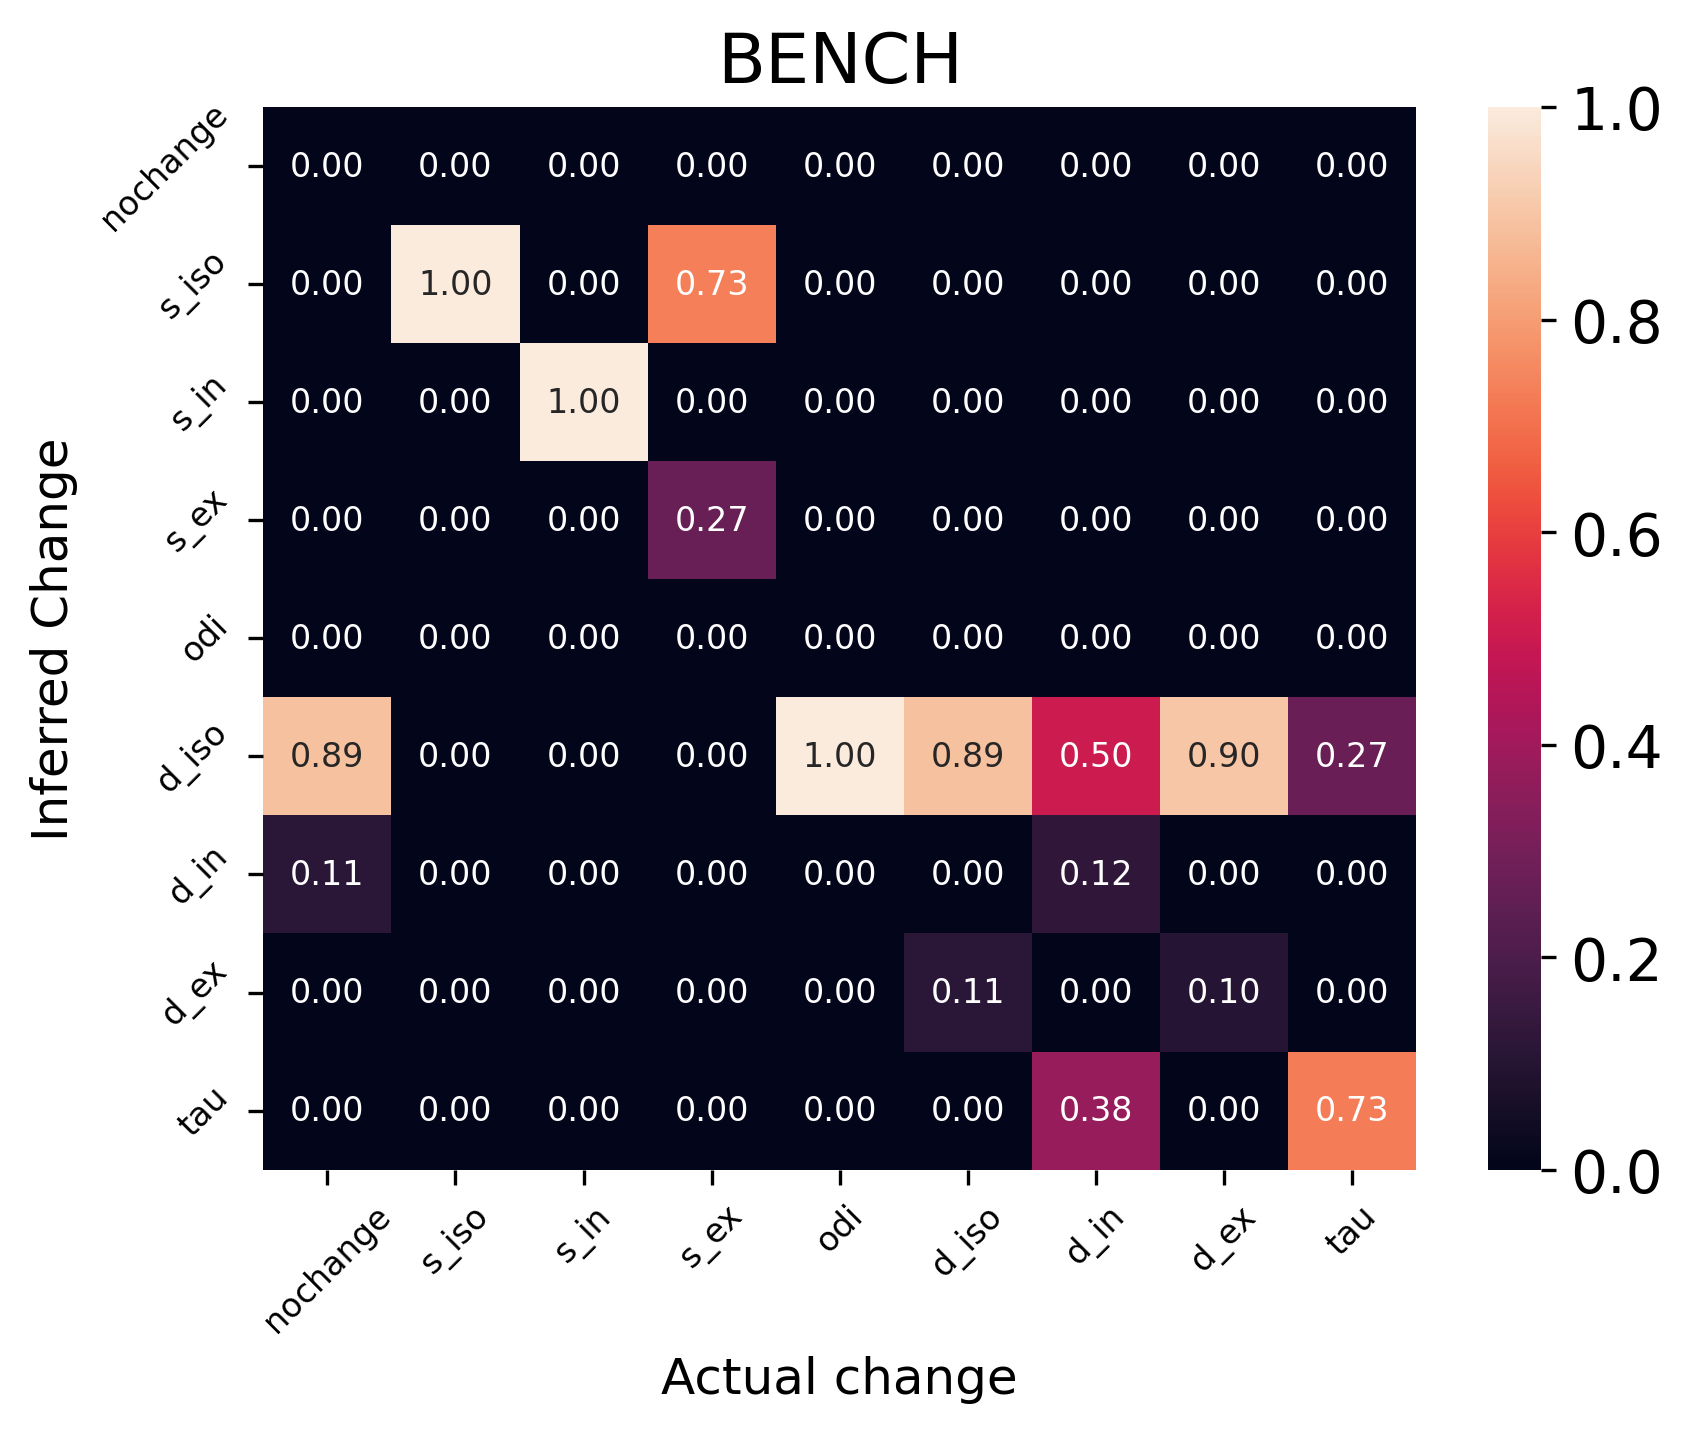

In [17]:
conf_mat = confusion_matrix(true_change, infered_change_bench, normalize='true')
plot.plot_conf_mat(conf_mat, param_names=mdl.model_names, title='BENCH')

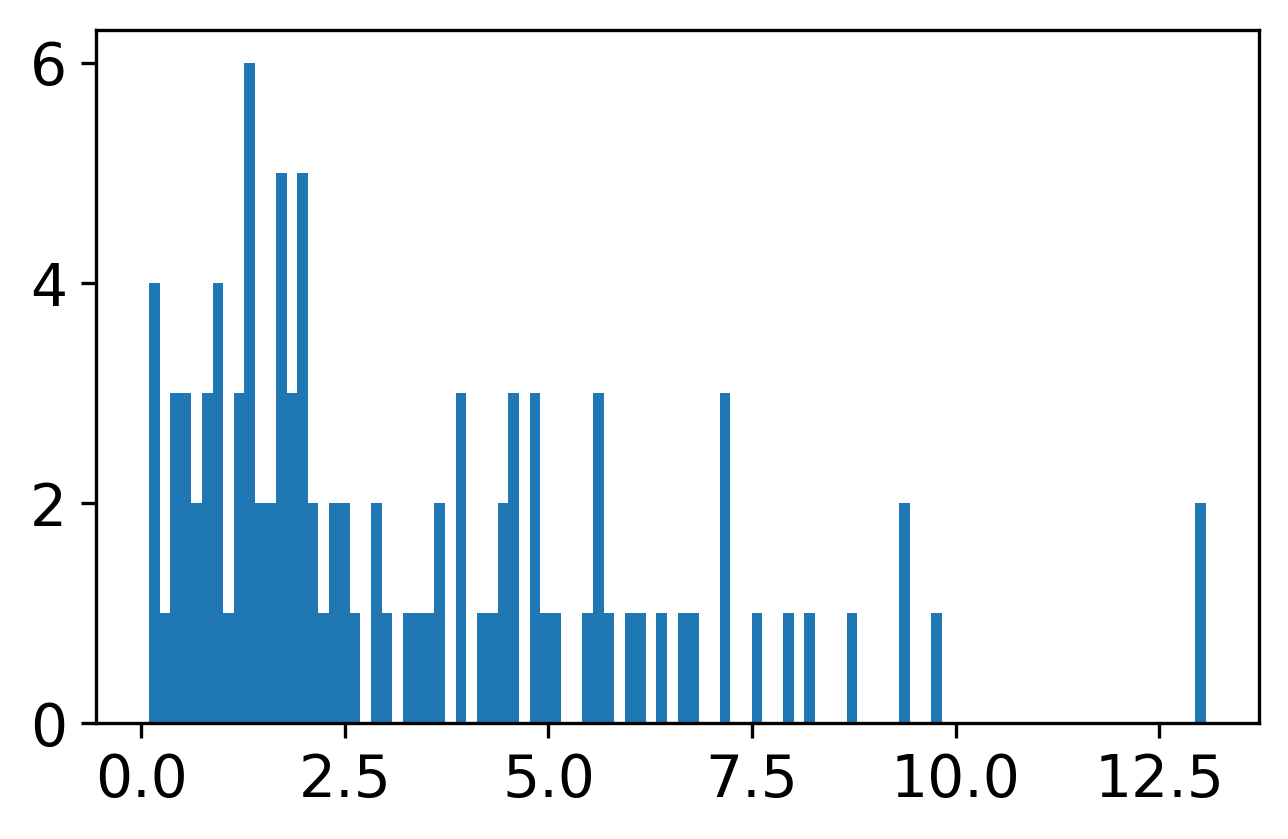

In [18]:
dv, offset, deviation = mdl.estimate_quality_of_fit(data, data2 - data, sn, infered_change_bench, amount)
plt.hist(deviation, 100);

In [19]:
def model_inv_tr(acq, noise_level, **p):
    return forward_model(bval=acq.bvals, bvec=acq.bvecs,**p) + noise_level * np.random.randn(acq.bvecs.shape[0])

def model_inv(**p):
    return forward_model(bval=acq.bvals, bvec=acq.bvecs,**p)

priors_inv = dict()
priors_inv['s_iso'] = st.truncnorm(loc=.5, scale=.2, a=-.5 / .2, b=np.inf)
priors_inv['s_in'] = st.truncnorm(loc=.5, scale=.2, a=-.5 / .2, b=np.inf)
priors_inv['s_ex'] = st.truncnorm(loc=.5, scale=.2, a=-.5 / .2, b=np.inf)
priors_inv.update(priors_bench)
del priors_inv[('s_iso', 's_in', 's_ex')]


tr_inv = change_model.Trainer(forward_model=model_inv_tr, kwargs={'noise_level':0, 'acq':acq}, priors=priors_inv)

true_change_inv, sig1, sig2, sn = tr_inv.generate_test_samples(parallel=False, 
    n_samples=n_test_samples, noise_std=noise_level, n_repeats=2, effect_size=effect_size)
    
def tmp_func(j):
    pe1, std1 = model_inversion.map_fit(sig1[j], np.eye(len(sig1[j])), model_inv, priors_inv)
    pe2, std2 = model_inversion.map_fit(sig2[j], np.eye(len(sig2[j])), model_inv, priors_inv)
        
    return model_inversion.infer_change(np.atleast_2d(pe1), np.atleast_2d(std1), 
                                        np.atleast_2d(pe2), np.atleast_2d(std2), alpha=0.05)

res = Parallel(n_jobs=-1, verbose=True)(delayed(tmp_func)(j) for j in range(n_test_samples))
infered_change_inv = np.squeeze(np.array(res)[:, 0])

Generating 100 test samples:


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
/Users/ecd25/miniconda3/envs/numba-py311/lib/python3.11/site-packages/bench/model_inversion.py:63: RuntimeWarning: invalid value encountered in sqrt
  std = 1 / np.sqrt(np.diag(h))
/Users/ecd25/miniconda3/envs/numba-py311/lib/python3.11/site-packages/bench/model_inversion.py:63: RuntimeWarning: invalid value encountered in sqrt
  std = 1 / np.sqrt(np.diag(h))
/Users/ecd25/miniconda3/envs/numba-py311/lib/python3.11/site-packages/bench/model_inversion.py:63: RuntimeWarning: invalid value encountered in sqrt
  std = 1 / np.sqrt(np.diag(h))
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    5.0s
/Users/ecd25/miniconda3/envs/numba-py311/lib/python3.11/site-packages/bench/model_inversion.py:63: RuntimeWarning: invalid value encountered in sqrt
  std = 1 / np.sqrt(np.diag(h))
/Users/ecd25/miniconda3/envs/numba-py311/lib/python3.11/site-packages/bench/model_inversion.py:63: RuntimeWarning: invalid value encounte

<Axes: title={'center': 'Parameter estimation'}, xlabel='Actual change', ylabel='Inferred Change'>

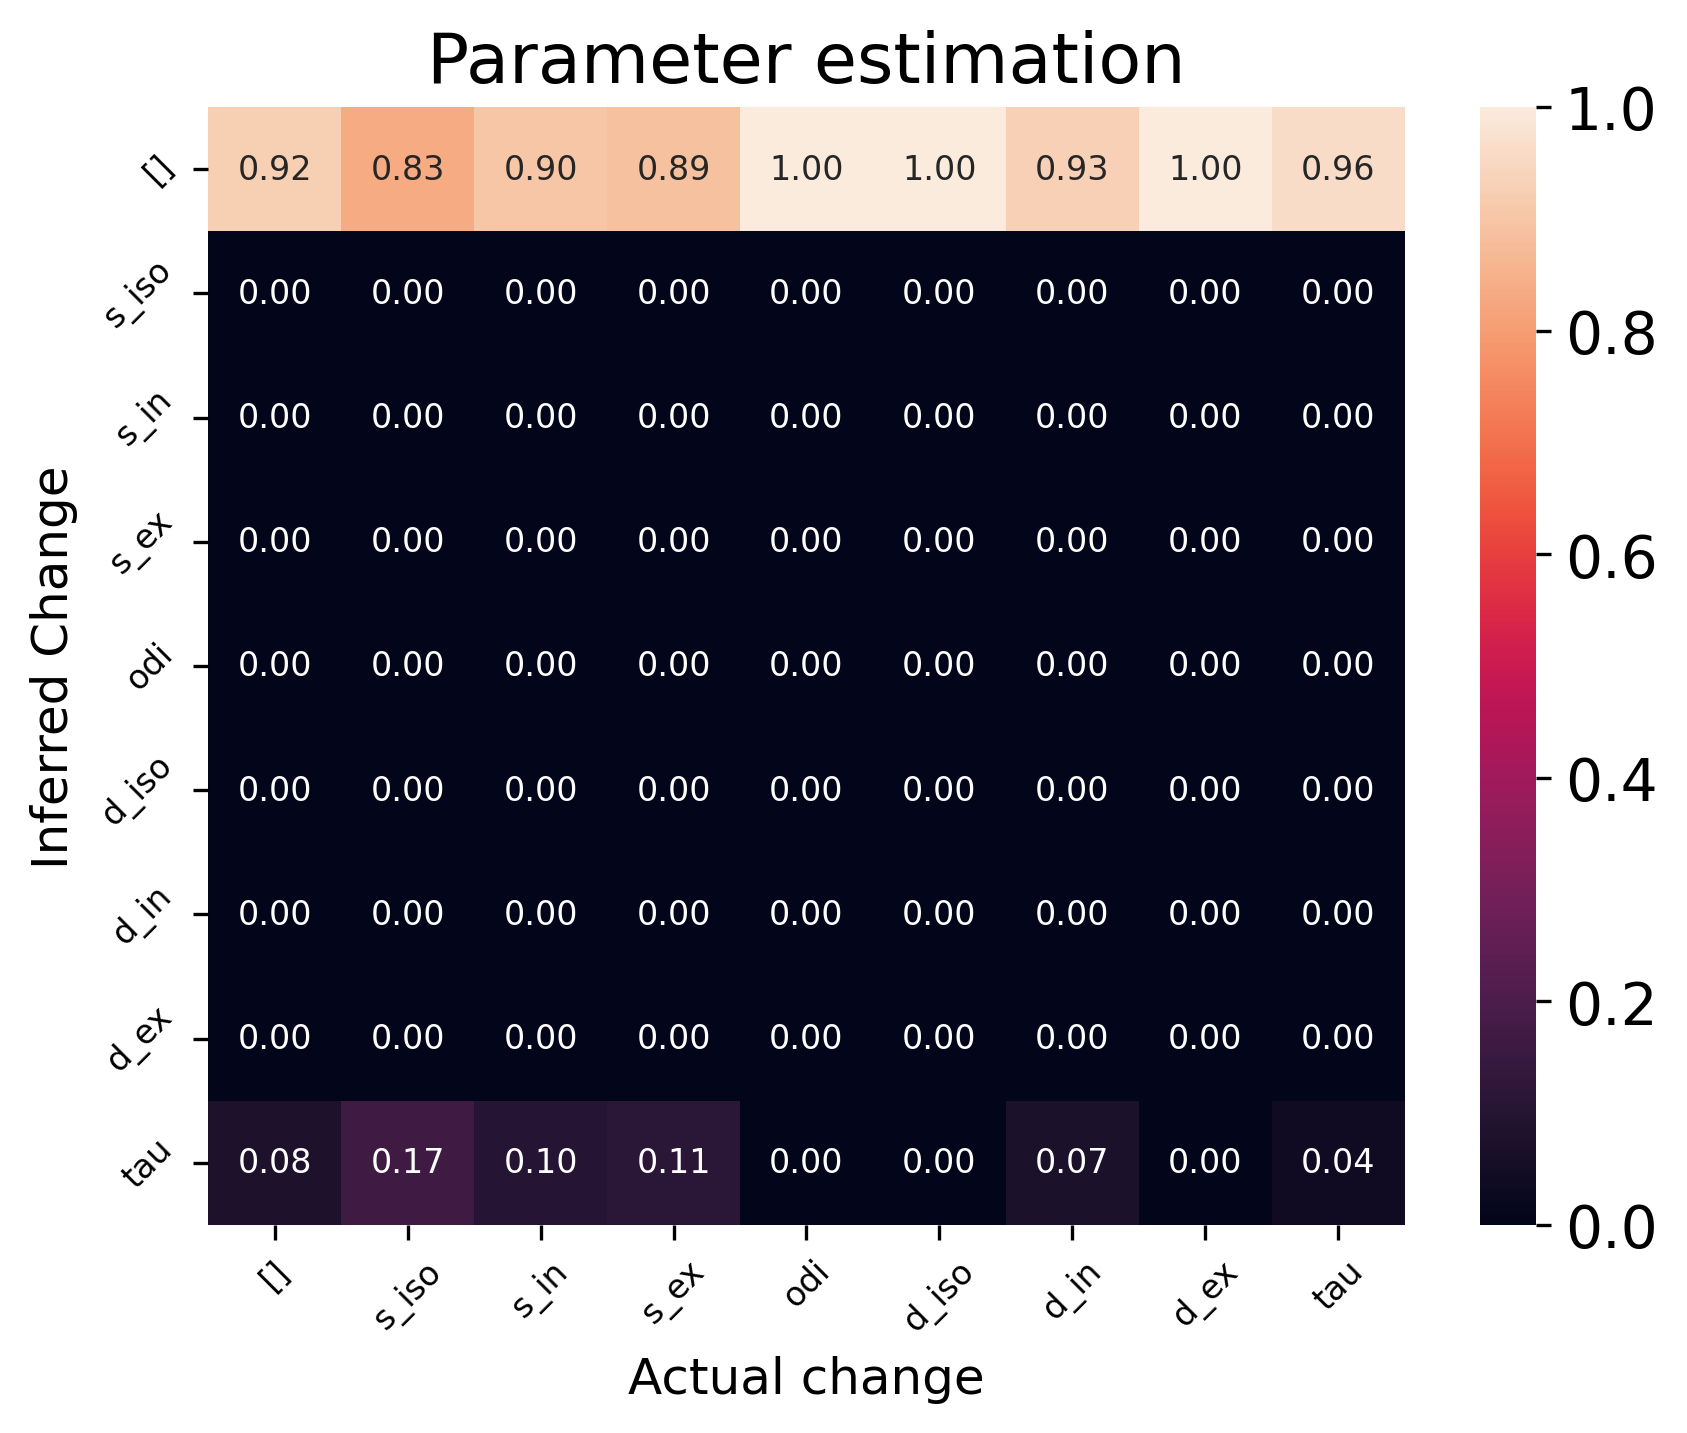

In [20]:
conf_mat_inv = confusion_matrix(true_change_inv, infered_change_inv, normalize='true')
plot.plot_conf_mat(conf_mat_inv, ['[]'] + list(priors_inv.keys()), title='Parameter estimation')

In [201]:
T1 = "/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/input/raw/sub-05/anat/sub-05_ses-01_T1w.nii.gz"
T1_brain = "/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/anat/sub-05_ses-01_T1w_brain.nii.gz"
MNI = "/Users/ecd25/fsl/data/standard/MNI152_T1_2mm_brain.nii.gz"
OMAT = "/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/xfms/sub-05_T1_2_MNI.mat"
COUT = "/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/xfms/sub-05_T1_2_MNI_warp.nii.gz"
T1_in_MNI = "/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/xfms/sub-05_T1_in_MNI.nii.gz"
CONFIG = "/Users/ecd25/fsl/etc/flirtsch/T1_2_MNI152_2mm.cnf"
NONLIN = "//Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/xfms/sub-05_T1_in_MNI_nonlin.nii.gz"

In [176]:
def betT1(T1, T1_brain):
    """
    Brain extraction using FSL's BET tool.
    """
    print(f"Running BET on {T1}")
    bet(T1, T1_brain)
    print(f"Brain extracted image saved to {T1_brain}")

In [13]:
print(T1)
print(T1_brain)


/Users/ecd25/Desktop/Fall_26/b0edema_test/sub-18/anat/sub-18_ses-01_T1w.nii.gz
/Users/ecd25/Desktop/Fall_26/b0edema_test/sub-18/anat/sub-18_ses-01_T1w_brain.nii.gz


In [14]:
betT1(T1, T1_brain)

Running BET on /Users/ecd25/Desktop/Fall_26/b0edema_test/sub-18/anat/sub-18_ses-01_T1w.nii.gz
Brain extracted image saved to /Users/ecd25/Desktop/Fall_26/b0edema_test/sub-18/anat/sub-18_ses-01_T1w_brain.nii.gz


In [152]:
def regT1(T1_brain, MNI, OMAT, T1_in_MNI):
    """
    
    """
    # Log the script execution details
    flirt (T1_brain, ref=MNI, dof=12, omat=OMAT, out=T1_in_MNI)
    print("Done")

In [153]:
regT1(T1_brain, MNI, OMAT, T1_in_MNI)

Done


In [155]:
def reg4wm(MNI, T1, OMAT, COUT, CONFIG, NONLIN):
    """
    
    """
    # Log the script execution details
    fnirt(ref=MNI, src=T1, aff=OMAT, cout=COUT, config=CONFIG, iout=NONLIN)
    print("Done")

In [156]:
reg4wm(MNI, T1, OMAT, COUT, CONFIG, NONLIN)

Done


In [ ]:
WM = "/Users/ecd25/Desktop/Fall_26/b0edema_test/output/derivatives/sub-05/anat/sub-05_ses-01_T1w_brain_NT_FAST_pve_2.nii.gz"
WM_in_MNI = "/Users/ecd25/Desktop/Fall_26/BENCH_4_WMSG/WM_in_MNI.nii.gz"

In [159]:
def app(WM, MNI, COUT, WM_in_MNI, MAT):
    """
    
    """
    applywarp(WM, ref=MNI, warp=COUT, out=WM_in_MNI, premat=OMAT)
    print("Done")

In [160]:
app(WM, MNI, COUT, WM_in_MNI, OMAT)

Done


In [202]:
import subprocess
from pathlib import Path

# ---------- Paths ----------

MNI = "/Users/ecd25/fsl/data/standard/MNI152_T1_2mm_brain.nii.gz"   # brain-only (FLIRT)
MNI_HEAD = "/Users/ecd25/fsl/data/standard/MNI152_T1_2mm.nii.gz"    # whole head (FNIRT / applywarp ref)

#WM = "/Users/ecd25/Desktop/Fall_26/b0edema_test/output/derivatives/sub-18/anat/sub-18_ses-01_T1w_brain_NT_FAST_pve_2.nii.gz"
#WM_in_MNI = "/Users/ecd25/Desktop/Fall_26/BENCH_4_WMSG/WM_in_MNI.nii.gz"

def _run(cmd):
    cmd = [str(c) for c in cmd]
    print(" ".join(cmd))
    subprocess.run(cmd, check=True)


def run_initial_affine(t1_brain, mni_brain, omat, out):
    """Step 1: FLIRT 12-dof affine, skull-stripped T1 -> MNI brain."""
    Path(omat).parent.mkdir(parents=True, exist_ok=True)
    _run([
        "flirt",
        "-in", t1_brain,
        "-ref", mni_brain,
        "-omat", omat,
        "-out", out,
        "-dof", 12,
        "-cost", "corratio",
        "-searchrx", -90, 90,
        "-searchry", -90, 90,
        "-searchrz", -90, 90,
    ])
    return omat


def run_nonlinear_registration(t1_head, mni_head, omat, config, cout, nonlin):
    """Step 2: FNIRT, whole-head T1 -> whole-head MNI, initialised with the affine."""
    _run([
        "fnirt",
        f"--in={t1_head}",
        f"--ref={mni_head}",
        f"--aff={omat}",
        f"--config={config}",
        f"--cout={cout}",
        f"--iout={nonlin}",
        "--verbose",
    ])
    return cout


def apply_warp(img, mni_ref, warp, out, interp="trilinear", binarize_thr=None):
    """
    Step 3: applywarp for an image in T1 space -> MNI space.
    For probabilistic maps (FAST pve), use trilinear; optionally binarize with binarize_thr.
    """
    _run([
        "applywarp",
        f"--in={img}",
        f"--ref={mni_ref}",
        f"--warp={warp}",
        f"--out={out}",
        f"--interp={interp}",
    ])
    if binarize_thr is not None:
        _run(["fslmaths", out, "-thr", binarize_thr, "-bin", out])
    return out


if __name__ == "__main__":
    run_initial_affine(T1_brain, MNI, OMAT, T1_in_MNI)
    run_nonlinear_registration(T1, MNI_HEAD, OMAT, CONFIG, COUT, NONLIN)

#    apply_warp(WM, MNI_HEAD, COUT, WM_in_MNI)

flirt -in /Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/anat/sub-05_ses-01_T1w_brain.nii.gz -ref /Users/ecd25/fsl/data/standard/MNI152_T1_2mm_brain.nii.gz -omat /Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/xfms/sub-05_T1_2_MNI.mat -out /Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/xfms/sub-05_T1_in_MNI.nii.gz -dof 12 -cost corratio -searchrx -90 90 -searchry -90 90 -searchrz -90 90
fnirt --in=/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/input/raw/sub-05/anat/sub-05_ses-01_T1w.nii.gz --ref=/Users/ecd25/fsl/data/standard/MNI152_T1_2mm.nii.gz --aff=/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/xfms/sub-05_T1_2_MNI.mat --config=/Users/ecd25/fsl/etc/flirtsch/T1_2_MNI152_2mm.cnf --cout=/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/xfms/sub-05_T1_2_MNI_warp.nii.gz --iout=//Users/ecd25/Desktop/BENCH/BENCH_Tutorial/on

In [164]:
apply_warp(WM, MNI_HEAD, COUT, WM_in_MNI, binarize_thr=0.5)

applywarp --in=/Users/ecd25/Desktop/Fall_26/b0edema_test/output/derivatives/sub-18/anat/sub-18_ses-01_T1w_brain_NT_FAST_pve_2.nii.gz --ref=/Users/ecd25/fsl/data/standard/MNI152_T1_2mm.nii.gz --warp=/Users/ecd25/Desktop/Fall_26/BENCH_4_WMSG/T1_2_MNI_warp.nii.gz --out=/Users/ecd25/Desktop/Fall_26/BENCH_4_WMSG/WM_in_MNI.nii.gz --interp=trilinear
fslmaths /Users/ecd25/Desktop/Fall_26/BENCH_4_WMSG/WM_in_MNI.nii.gz -thr 0.5 -bin /Users/ecd25/Desktop/Fall_26/BENCH_4_WMSG/WM_in_MNI.nii.gz


'/Users/ecd25/Desktop/Fall_26/BENCH_4_WMSG/WM_in_MNI.nii.gz'

In [ ]:
DATA = "/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs s_many/output/derivatives/sub-05/dwi/b0b1600.nii.gz"
bvecs = "/Users/ecd25/Desktop/Fall_26/protocols/on_1600_bvecs"
bvals = "/Users/ecd25/Desktop/Fall_26/protocols/on_1600.bval"
SUM = "/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/summaries/sub-05"
DIFF2STD = "/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/xfms/diff2standard_warp.nii.gz"
B0_in_MNI = "/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/xfms/sub-05_b0_in_MNI.nii.gz"
DIFF2STR = "/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/xfms/diff2str" 
B0 = "/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/dwi/b0_av.nii.gz"
#WMSEG = "/Users/ecd25/Desktop/Fall_26/b0edema_test/sub-05/WM_SEG.nii.gz"
FULL_DATA = "/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/input/raw/sub-05/dwi/sub-05_ses-01_dwi.nii.gz"
B0_all = "/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/dwi/b0_all.nii.gz"
t1_2_mni_warp = "/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/xfms/sub-05_T1_2_MNI_warp.nii.gz"

In [ ]:
!select_dwi_vols $FULL_DATA $bvals $DATA 1600 -b 0
!select_dwi_vols $FULL_DATA $bvals $B0_all 0
!fslmaths $B0_all -Tmean $B0

Extracting bvals=1600 0
volume list = 0,1,2,3,4,5,6,7,8,9,10,11
/Users/ecd25/fsl/bin/fslselectvols -i /Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/input/raw/sub-05/dwi/sub-05_ses-01_dwi.nii.gz -o /Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/dwi/b0b1600.nii.gz --vols=0,1,2,3,4,5,6,7,8,9,10,11


In [211]:
def _run(cmd):
    cmd = [str(c) for c in cmd]
    print(" ".join(cmd))
    subprocess.run(cmd, check=True)


def run_diff2standard(b0, t1, t1_brain, t1_2_mni_warp, mni_ref,
                      diff2str_prefix, diff2std_warp, wm_pve=None, wmseg_out=None):
    """
    Build a diffusion -> MNI warp.

    1) epi_reg:     b0 -> T1 (BBR), writes <prefix>.mat
    2) convertwarp: combine <prefix>.mat with the T1 -> MNI FNIRT warp

    wm_pve : optional FAST WM partial-volume map. If given it is binarized (>0.5)
             and passed to epi_reg as --wmseg, which saves epi_reg from re-running FAST.
    Returns: path to the diff2standard warp field.
    """
    Path(diff2str_prefix).parent.mkdir(parents=True, exist_ok=True)

    # --- Step 1: diffusion -> T1 ---
    epi_cmd = [
        "epi_reg",
        f"--epi={b0}",
        f"--t1={t1}",
        f"--t1brain={t1_brain}",
        f"--out={diff2str_prefix}",
    ]
    _run(epi_cmd)

    # --- Step 2: concatenate with T1 -> MNI warp ---
    _run([
        "convertwarp",
        f"--ref={mni_ref}",
        f"--premat={diff2str_prefix}.mat",
        f"--warp1={t1_2_mni_warp}",
        f"--out={diff2std_warp}",
    ])
    return diff2std_warp

def apply_diff2standard(img, mni_ref, diff2std_warp, out, interp="trilinear"):
    """Move any diffusion-space image (b0, FA, MD, ...) into MNI space."""
    _run([
        "applywarp",
        f"--in={img}",
        f"--ref={mni_ref}",
        f"--warp={diff2std_warp}",
        f"--out={out}",
        f"--interp={interp}",
    ])
    return out

if __name__ == "__main__":
    run_diff2standard(B0, T1, T1_brain, COUT, MNI_HEAD,
                      DIFF2STR, DIFF2STD)

epi_reg --epi=/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/dwi/b0_av.nii.gz --t1=/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/input/raw/sub-05/anat/sub-05_ses-01_T1w.nii.gz --t1brain=/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/anat/sub-05_ses-01_T1w_brain.nii.gz --out=/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/xfms/diff2str
Running FAST segmentation
FLIRT pre-alignment
Running BBR
1.006244 0.992702 -0.097848 0.070494 0.000000 0.099533 0.994817 -0.020790 0.000000 -0.068094 0.027655 0.997296 0.000000 -4.639233 10.561099 -4.999495 1.000000 
convertwarp --ref=/Users/ecd25/fsl/data/standard/MNI152_T1_2mm.nii.gz --premat=/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/xfms/diff2str.mat --warp1=/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/xfms/sub-05_T1_2_MNI_warp.nii.gz --out=/Users/ecd25/Desktop/BENCH/BENCH_Tu

In [212]:
apply_diff2standard(B0, MNI_HEAD, DIFF2STD, B0_in_MNI)

applywarp --in=/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/dwi/b0_av.nii.gz --ref=/Users/ecd25/fsl/data/standard/MNI152_T1_2mm.nii.gz --warp=/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/xfms/diff2standard_warp.nii.gz --out=/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/xfms/sub-05_b0_in_MNI.nii.gz --interp=trilinear


'/Users/ecd25/Desktop/BENCH/BENCH_Tutorial/one_vs_many/output/derivatives/sub-05/xfms/sub-05_b0_in_MNI.nii.gz'

In [213]:
!bench diff-summary --data $DATA --bvecs $bvecs --bvals $bvals --mask $WM_in_MNI --xfm $DIFF2STD --summarytype dt --output $SUM

/Users/ecd25/miniconda3/envs/numba-py311/lib/python3.11/site-packages/bench/dti.py:89: RuntimeWarning: divide by zero encountered in log
  d = - np.log(signal) @ np.linalg.pinv(g).T / bval
Traceback (most recent call last):
  File "/Users/ecd25/miniconda3/envs/numba-py311/bin/bench", line 6, in <module>
    sys.exit(main())
             ^^^^^^
  File "/Users/ecd25/miniconda3/envs/numba-py311/lib/python3.11/site-packages/bench/main.py", line 24, in main
    args.func(args)
  File "/Users/ecd25/miniconda3/envs/numba-py311/lib/python3.11/site-packages/bench/main.py", line 273, in summary_from_cli
    summaries = dti.fit_dti(data[valid_idx], acq)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/ecd25/miniconda3/envs/numba-py311/lib/python3.11/site-packages/bench/dti.py", line 44, in fit_dti
    sm = summary_np(shell_signal, bvecs, this_shell.bvals, s0)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/ecd25/miniconda3/envs/numba-py311/lib/python3

In [214]:
print(bvecs)

/Users/ecd25/Desktop/Fall_26/protocols/on_1600_bvecs


In [215]:
!cat $bvecs

0.423736  -0.993013 -0.372231 0.765647 0.313532 0.759542 -0.426572 -0.0205898 -2.74207e-09 -0.0397033 -0.0397033 -0.0397033
-0.469115  0.100841 -0.681517 -0.59296 0.393229 0.479817 -0.90093 -0.848538 -4.74623e-09 0.233668 0.233668 0.233668
0.774841  -0.0612929 -0.630063 -0.249367 -0.864331 -0.439172 0.0797559 0.528733 1 0.971505 0.971505 0.971505


In [216]:
!cat $bvals

1600  1600 1600 1600 1600 1600 1600 1600 0 0.1 0.01 0.001
